In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **INSTALLING AND IMPORTS OF LIBRARY**

In [4]:
!pip -q install pandas numpy pyarrow matplotlib seaborn scipy scikit-learn \
    yfinance datasets huggingface_hub tqdm

In [5]:
import os
import gc
import json
import warnings
from pathlib import Path
from datasets import load_dataset 
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


DATASET = "vishnun0027/indian-market-historical-ohlcv"

OUTPUT_DIR = Path("indian_market_audit")
PLOT_DIR = OUTPUT_DIR / "plots"

OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("Environment ready.")
print("Dataset:", DATASET)
print("Output directory:", OUTPUT_DIR)

Environment ready.
Dataset: vishnun0027/indian-market-historical-ohlcv
Output directory: indian_market_audit


# **LOADING INDIA STOCK DATASET FROM HUGGING FACE**

In [6]:
ds = load_dataset(
    DATASET,
    data_dir="stocks",
    split="train"
)
print(ds)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2624 [00:00<?, ?it/s]

stocks/3IINFOLTD.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

stocks/3BBLACKBIO.parquet:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

stocks/20MICRONS.parquet:   0%|          | 0.00/156k [00:00<?, ?B/s]

...

stocks/ZUARIIND.parquet:   0%|          | 0.00/232k [00:00<?, ?B/s]

stocks/ZYDUSLIFE.parquet:   0%|          | 0.00/292k [00:00<?, ?B/s]

stocks/ZYDUSWELL.parquet:   0%|          | 0.00/187k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits', 'symbol'],
    num_rows: 7692540
})


# ***AUDIT OF DATASET***

***SEEING THE NUMBER OF ROWS AND THE DATA TYPE OF EACH COLUMN***

In [7]:
print("Number of rows:", f"{len(ds):,}")
print("Columns:")
print(ds.column_names)

print("\nFeatures:")
print(ds.features)

Number of rows: 7,692,540
Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits', 'symbol']

Features:
{'date': Value('date32'), 'open': Value('float64'), 'high': Value('float64'), 'low': Value('float64'), 'close': Value('float64'), 'adj_close': Value('float64'), 'volume': Value('int64'), 'dividends': Value('float64'), 'stock_splits': Value('float64'), 'symbol': Value('large_string')}


# ***CONVERTING TO PANDAS***

In [8]:
df = ds.to_pandas()

print("Shape:", df.shape)

display(df.head())

print("\nMemory usage:")
print(
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

Shape: (7692540, 10)


,date,open,high,low,close,adj_close,volume,dividends,stock_splits,symbol
0,2008-10-06,40.00,40.00,15.800,16.775,14.586986,23501600,0.0,0.0,20MICRONS
1,2008-10-07,16.00,19.00,13.925,15.025,13.065243,9113400,0.0,0.0,20MICRONS
2,2008-10-08,14.00,14.60,12.550,13.250,11.521762,2464384,0.0,0.0,20MICRONS
3,2008-10-10,12.45,12.45,10.825,11.600,10.086977,1207928,0.0,0.0,20MICRONS
4,2008-10-13,12.15,13.30,11.650,12.325,10.717413,898692,0.0,0.0,20MICRONS



Memory usage:
1176.50 MB


# ***MAKE DATAFRAME***

In [7]:
schema_audit = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_pct": [
        df[c].isna().mean() * 100
        for c in df.columns
    ],
    "unique_values": [
        df[c].nunique(dropna=True)
        for c in df.columns
    ]
})

schema_audit["missing_pct"] = schema_audit["missing_pct"].round(4)
display(schema_audit)

schema_audit.to_csv(
    OUTPUT_DIR / "schema_audit.csv",
    index=False
)

,column,dtype,non_null,missing,missing_pct,unique_values
0,date,object,7692540,0,0.0000,9026
1,open,float64,7692540,0,0.0000,664742
2,high,float64,7692540,0,0.0000,694427
3,low,float64,7692540,0,0.0000,697867
4,close,float64,7663826,28714,0.3733,854340
5,adj_close,float64,7663826,28714,0.3733,4376209
6,volume,int64,7692540,0,0.0000,1893686
7,dividends,float64,7692540,0,0.0000,2018
8,stock_splits,float64,7692540,0,0.0000,71
9,symbol,object,7692540,0,0.0000,2624


# ***DATATYPE NORMALIZATION***

In [8]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

numeric_columns = [
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "dividends",
    "stock_splits"
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df["symbol"] = (
    df["symbol"]
    .astype("string")
    .str.upper()
    .str.strip()
)

print(df.dtypes)

date            datetime64[ns]
open                   float64
high                   float64
low                    float64
close                  float64
adj_close              float64
volume                   int64
dividends              float64
stock_splits           float64
symbol          string[python]
dtype: object


In [9]:
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

print(
    "Number of trading dates:",
    df["date"].nunique()
)

print(
    "Number of symbols:",
    df["symbol"].nunique()
)

Minimum date: 1991-01-02 00:00:00
Maximum date: 2026-09-25 00:00:00
Number of trading dates: 9026
Number of symbols: 2624


In [10]:
symbol_coverage = (
    df.groupby("symbol")
      .agg(
          rows=("symbol", "size"),
          first_date=("date", "min"),
          last_date=("date", "max"),
          trading_days=("date", "nunique")
      )
      .sort_values("rows", ascending=False)
)

display(symbol_coverage.head(30))

symbol_coverage.to_csv(
    OUTPUT_DIR / "symbol_coverage.csv"
)

,rows,first_date,last_date,trading_days
symbol,,,,
TMPV,9022,1991-01-02,2026-09-25,9022
TATAINVEST,7719,1996-01-01,2026-09-25,7719
WIPRO,7719,1996-01-01,2026-09-25,7719
TITAN,7719,1996-01-01,2026-09-25,7719
VEDL,7719,1996-01-01,2026-09-25,7719
EIHOTEL,7719,1996-01-01,2026-09-25,7719
TATASTEEL,7719,1996-01-01,2026-09-25,7719
IDBI,7719,1996-01-01,2026-09-25,7719
SAIL,7719,1996-01-01,2026-09-25,7719


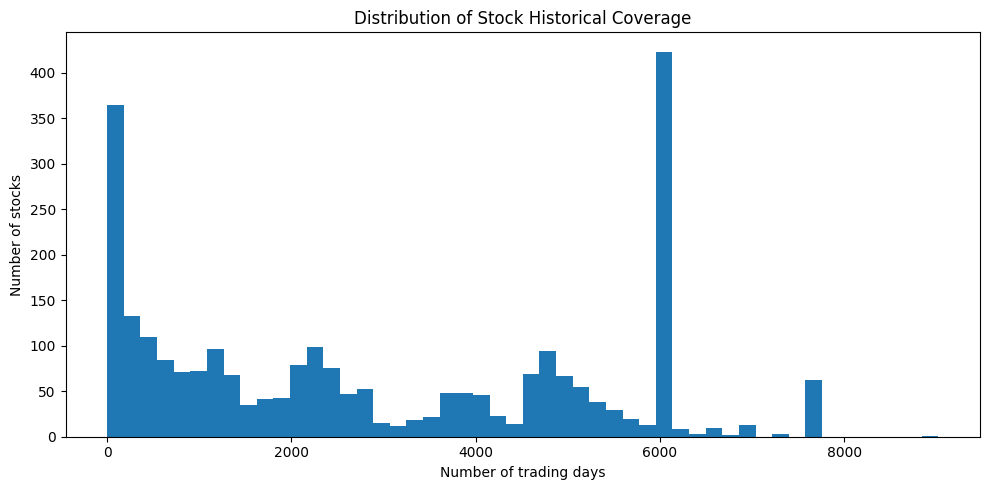

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    symbol_coverage["trading_days"],
    bins=50
)

plt.xlabel("Number of trading days")
plt.ylabel("Number of stocks")
plt.title("Distribution of Stock Historical Coverage")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "symbol_coverage_distribution.png",
    dpi=150
)

plt.show()

# ***MISSING VALUE AUDIT***

In [12]:
missing_audit = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing_audit = missing_audit.sort_values(
    "missing_pct",
    ascending=False
)

missing_audit["missing_pct"] = (
    missing_audit["missing_pct"]
    .round(4)
)

display(missing_audit)

missing_audit.to_csv(
    OUTPUT_DIR / "missing_value_audit.csv",
    index=False
)

,column,missing_count,missing_pct
close,close,28714,0.3733
adj_close,adj_close,28714,0.3733
open,open,0,0.0000
date,date,0,0.0000
low,low,0,0.0000
high,high,0,0.0000
volume,volume,0,0.0000
dividends,dividends,0,0.0000
stock_splits,stock_splits,0,0.0000
symbol,symbol,0,0.0000


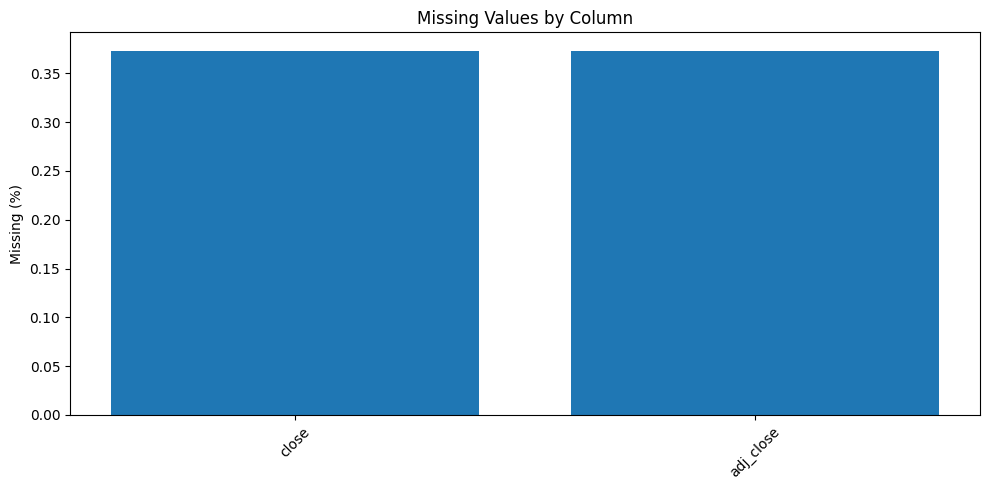

In [13]:
plt.figure(figsize=(10, 5))

missing_audit_plot = missing_audit[
    missing_audit["missing_count"] > 0
]

plt.bar(
    missing_audit_plot["column"],
    missing_audit_plot["missing_pct"]
)

plt.xticks(rotation=45)

plt.ylabel("Missing (%)")
plt.title("Missing Values by Column")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "missing_values.png",
    dpi=150
)

plt.show()

# ***DUPLICATE AUDIT***

In [14]:
exact_duplicates = df.duplicated().sum()

key_duplicates = df.duplicated(
    subset=["symbol", "date"]
).sum()

print(
    "Exact duplicate rows:",
    f"{exact_duplicates:,}"
)

print(
    "Duplicate symbol-date records:",
    f"{key_duplicates:,}"
)

duplicate_keys = (
    df.groupby(["symbol", "date"])
      .size()
      .reset_index(name="count")
)

duplicate_keys = duplicate_keys[
    duplicate_keys["count"] > 1
]

print(
    "Duplicate symbol-date combinations:",
    len(duplicate_keys)
)

display(duplicate_keys.head(20))

Exact duplicate rows: 0
Duplicate symbol-date records: 0
Duplicate symbol-date combinations: 0


,symbol,date,count


# ***OHLC INTEGRITY***

In [15]:
df["bad_high_low"] = (
    df["high"] < df["low"]
)

df["bad_high_open"] = (
    df["high"] < df["open"]
)

df["bad_high_close"] = (
    df["high"] < df["close"]
)

df["bad_low_open"] = (
    df["low"] > df["open"]
)

df["bad_low_close"] = (
    df["low"] > df["close"]
)

ohlc_audit = pd.DataFrame({
    "check": [
        "high < low",
        "high < open",
        "high < close",
        "low > open",
        "low > close"
    ],
    "violations": [
        df["bad_high_low"].sum(),
        df["bad_high_open"].sum(),
        df["bad_high_close"].sum(),
        df["bad_low_open"].sum(),
        df["bad_low_close"].sum()
    ]
})

ohlc_audit["violation_pct"] = ohlc_audit["violations"] /len(df) * 100)
display(ohlc_audit)

,check,violations,violation_pct
0,high < low,1,0.000013
1,high < open,27,0.000351
2,high < close,11,0.000143
3,low > open,21,0.000273
4,low > close,0,0.000000


# ***DISCRIPTIVE STASTISTICS***

In [9]:
price_stats = df[[
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume",
        "dividends",
        "stock_splits"
    ]
].describe(
    percentiles=[
        0.001,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
        0.999
    ]
).T

display(price_stats)

price_stats.to_csv(
    OUTPUT_DIR / "price_statistics.csv"
)

,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
open,7692540.0,4.674070e+02,3.193955e+03,0.000000,0.20,0.918919,3.86,25.299999,85.000000,291.255089,1.547500e+03,5.370000e+03,3.500000e+04,6.740000e+05
high,7692540.0,4.756911e+02,3.270303e+03,0.023907,0.22,0.950000,3.95,25.975000,87.000000,297.475006,1.574531e+03,5.449500e+03,3.552608e+04,7.350000e+05
low,7692540.0,4.586941e+02,3.114682e+03,0.000000,0.20,0.900000,3.76,24.650000,83.099998,285.250000,1.518962e+03,5.281000e+03,3.447500e+04,6.321000e+05
close,7663826.0,4.650647e+02,3.181459e+03,0.023907,0.20,0.915935,3.85,25.181704,84.650002,290.100006,1.539753e+03,5.341637e+03,3.485602e+04,6.750000e+05
adj_close,7663826.0,4.453669e+02,3.156412e+03,-0.130537,0.10,0.736670,3.35,21.959054,75.779984,270.543182,1.476635e+03,5.166117e+03,3.446594e+04,6.750000e+05
volume,7692540.0,1.627612e+06,1.296362e+07,0.000000,0.00,0.000000,50.00,10187.000000,67358.000000,417235.000000,5.790034e+06,2.720499e+07,1.407296e+08,4.097564e+09
dividends,7692540.0,1.490050e-02,1.147065e+00,0.000000,0.00,0.000000,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2.500000e+00,1.000000e+03
stock_splits,7692540.0,7.199853e-04,6.428390e-02,0.000000,0.00,0.000000,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01


# ***AUDITING RETURNS***

In [17]:
df = df.sort_values(
    ["symbol", "date"]
).reset_index(drop=True)

df["daily_return"] = (
    df.groupby("symbol")["adj_close"]
      .pct_change()
)

df["log_return"] = (
    df.groupby("symbol")["adj_close"]
      .transform(lambda x: np.log(x).diff())
)

print(
    df[
        ["symbol", "date", "adj_close",
         "daily_return", "log_return"]
    ].head(20)
)

       symbol       date  adj_close  daily_return  log_return
0   20MICRONS 2008-10-06  14.586986           NaN         NaN
1   20MICRONS 2008-10-07  13.065243     -0.104322   -0.110174
2   20MICRONS 2008-10-08  11.521762     -0.118136   -0.125718
3   20MICRONS 2008-10-10  10.086977     -0.124528   -0.132992
4   20MICRONS 2008-10-13  10.717413      0.062500    0.060625
5   20MICRONS 2008-10-14   9.630454     -0.101420   -0.106939
6   20MICRONS 2008-10-15  10.586977      0.099323    0.094694
7   20MICRONS 2008-10-16  11.521762      0.088296    0.084613
8   20MICRONS 2008-10-17   9.543498     -0.171698   -0.188377
9   20MICRONS 2008-10-20   9.456541     -0.009112   -0.009153
10  20MICRONS 2008-10-21   9.434801     -0.002299   -0.002302
11  20MICRONS 2008-10-22   8.826105     -0.064516   -0.066691
12  20MICRONS 2008-10-23   8.260886     -0.064039   -0.066182
13  20MICRONS 2008-10-24   7.173928     -0.131579   -0.141079
14  20MICRONS 2008-10-27   6.347839     -0.115152   -0.122339
15  20MI

# ***RETURN OUTLIER AUDIT***

In [18]:
return_stats = df["daily_return"].describe(
    percentiles=[
        0.001,
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
        0.999
    ]
)

display(return_stats)

extreme_returns = df[
    df["daily_return"].abs() > 0.20
].copy()

print(
    "Observations with absolute daily return > 20%:",
    len(extreme_returns)
)

display(
    extreme_returns[
        [
            "symbol",
            "date",
            "close",
            "adj_close",
            "daily_return",
            "stock_splits"
        ]
    ].head(50)
)

count    7.689916e+06
mean     3.604771e-03
std      2.528889e+00
min     -2.946443e+01
0.1%    -1.492960e-01
1%      -7.470658e-02
5%      -4.527712e-02
50%      0.000000e+00
95%      4.999994e-02
99%      1.001040e-01
99.9%    1.999999e-01
max      3.369478e+03
Name: daily_return, dtype: float64

Observations with absolute daily return > 20%: 7894


,symbol,date,close,adj_close,daily_return,stock_splits
125,20MICRONS,2009-04-21,10.475000,9.108714,0.200573,0.0
318,20MICRONS,2010-01-29,26.799999,23.304398,0.200448,0.0
432,20MICRONS,2010-07-15,27.049999,23.521790,0.200888,0.0
3266,20MICRONS,2022-01-10,89.400002,87.899948,0.200000,0.0
9430,3IINFOLTD,2009-05-12,593.500000,550.827209,0.208758,0.0
12503,3IINFOLTD,2021-10-22,31.000000,31.000000,-0.633136,0.0
19882,3PLAND,2008-10-10,12.400000,12.312982,-0.200000,0.0
19925,3PLAND,2008-12-16,9.600000,9.532632,0.200000,0.0
19946,3PLAND,2009-01-19,8.550000,8.490000,-0.256522,0.0
20159,3PLAND,2009-12-02,17.549999,17.426842,0.202055,0.0


# ***COPERATE ACTION AUDIT***

In [19]:
split_events = df[
    df["stock_splits"].notna() &
    (df["stock_splits"] != 0) &
    (df["stock_splits"] != 1)
].copy()

dividend_events = df[
    df["dividends"].notna() &
    (df["dividends"] != 0)
].copy()

print(
    "Stock split observations:",
    len(split_events)
)

print(
    "Dividend observations:",
    len(dividend_events)
)

display(split_events.head(20))
display(dividend_events.head(20))

Stock split observations: 1575
Dividend observations: 24112


,date,open,high,low,close,adj_close,volume,dividends,stock_splits,symbol,bad_high_low,bad_high_open,bad_high_close,bad_low_open,bad_low_close,daily_return,log_return
1060,2013-01-28,67.900002,80.699997,67.900002,71.750000,66.624771,2661516,0.0,2.000000,20MICRONS,False,False,False,False,False,5.243855e-02,5.110990e-02
7438,2023-03-02,489.950012,489.950012,435.549988,441.049988,416.901703,215418,0.0,2.000000,360ONE,False,False,False,False,False,-5.131704e-03,-5.144917e-03
9015,2007-08-27,1350.000000,1447.500000,1350.000000,1357.500000,1242.010620,19046,0.0,2.000000,3IINFOLTD,False,False,False,False,False,-1.272731e-02,-1.280899e-02
12466,2021-08-30,84.500000,84.500000,84.500000,84.500000,84.500000,0,0.0,0.100000,3IINFOLTD,False,False,False,False,False,0.000000e+00,0.000000e+00
36092,2022-09-13,86.666664,86.666664,84.000000,84.000000,81.407829,13500,0.0,1.500000,AAATECH,False,False,False,False,False,-5.227542e-02,-5.369135e-02
36093,2022-09-14,85.000000,92.400002,85.000000,92.400002,89.548630,18000,0.0,1.500000,AAATECH,False,False,False,False,False,1.000002e-01,9.531038e-02
38138,2020-03-26,3.485000,3.485000,3.485000,3.485000,3.485000,30000,0.0,1.500000,AAKASH,False,False,False,False,False,-8.849167e-02,-9.265455e-02
38599,2022-02-03,29.400000,31.049999,28.100000,31.049999,31.049999,2085770,0.0,10.000000,AAKASH,False,False,False,False,False,1.000885e-01,9.539066e-02
41390,2019-08-29,12.142857,12.142857,12.142857,12.142857,11.802582,0,0.0,1.100000,AARON,False,False,False,False,False,8.080218e-08,8.080218e-08
41640,2020-09-03,14.750000,15.250000,14.500000,15.250000,15.024781,63000,0.0,1.909091,AARON,False,False,False,False,False,7.828295e-02,7.536991e-02


,date,open,high,low,close,adj_close,volume,dividends,stock_splits,symbol,bad_high_low,bad_high_open,bad_high_close,bad_low_open,bad_low_close,daily_return,log_return
452,2010-08-12,25.825001,26.625000,25.825001,26.400000,23.393835,33508,0.50,0.0,20MICRONS,False,False,False,False,False,0.005714,0.005698
698,2011-08-04,26.750000,26.750000,24.150000,25.975000,23.671749,185386,0.75,0.0,20MICRONS,False,False,False,False,False,-0.015166,-0.015282
938,2012-07-26,48.250000,48.825001,47.474998,48.075001,44.640911,294672,0.90,0.0,20MICRONS,False,False,False,False,False,0.010510,0.010455
1220,2013-09-19,30.600000,31.500000,30.400000,30.650000,28.929489,72443,0.50,0.0,20MICRONS,False,False,False,False,False,0.009885,0.009836
2255,2017-12-05,55.650002,55.650002,53.650002,54.549999,51.859638,192616,0.40,0.0,20MICRONS,False,False,False,False,False,-0.015343,-0.015462
2445,2018-09-10,49.349998,52.900002,48.299999,49.900002,47.785606,302119,0.35,0.0,20MICRONS,False,False,False,False,False,0.041754,0.040906
2816,2020-03-19,22.950001,24.799999,21.049999,22.250000,21.876665,411131,0.60,0.0,20MICRONS,False,False,False,False,False,-0.008909,-0.008949
3648,2023-07-26,116.199997,116.199997,111.300003,116.199997,115.024323,414594,0.75,0.0,20MICRONS,False,False,False,False,False,0.049684,0.048489
3883,2024-07-12,221.699997,223.910004,215.699997,218.360001,217.378265,181272,1.25,0.0,20MICRONS,False,False,False,False,False,-0.007906,-0.007937
4140,2025-07-24,275.000000,275.660004,269.000000,270.329987,270.329987,157093,1.25,0.0,20MICRONS,False,False,False,False,False,-0.023304,-0.023580


# ***RAW VS ADJUSTED PRICE***

***COMPARING BOTH PRICE***

In [20]:
df["adjustment_ratio"] = (
    df["adj_close"] /
    df["close"]
)

display(
    df[
        [
            "symbol",
            "date",
            "close",
            "adj_close",
            "adjustment_ratio"
        ]
    ].head(20)
)

print(
    "Adjustment ratio summary:"
)

display(
    df["adjustment_ratio"].describe()
)

,symbol,date,close,adj_close,adjustment_ratio
0,20MICRONS,2008-10-06,16.775,14.586986,0.869567
1,20MICRONS,2008-10-07,15.025,13.065243,0.869567
2,20MICRONS,2008-10-08,13.250,11.521762,0.869567
3,20MICRONS,2008-10-10,11.600,10.086977,0.869567
4,20MICRONS,2008-10-13,12.325,10.717413,0.869567
5,20MICRONS,2008-10-14,11.075,9.630454,0.869567
6,20MICRONS,2008-10-15,12.175,10.586977,0.869567
7,20MICRONS,2008-10-16,13.250,11.521762,0.869567
8,20MICRONS,2008-10-17,10.975,9.543498,0.869567
9,20MICRONS,2008-10-20,10.875,9.456541,0.869567


Adjustment ratio summary:


count    7.663826e+06
mean     9.133277e-01
std      1.333513e-01
min     -4.538025e-01
25%      8.782007e-01
50%      9.752788e-01
75%      1.000000e+00
max      1.000000e+00
Name: adjustment_ratio, dtype: float64

# ***FEATURE ENGINEERING***

In [21]:
g = df.groupby("symbol", group_keys=False)

# Moving averages
for window in [5, 10, 20, 50, 100, 200]:

    df[f"sma_{window}"] = (
        g["adj_close"]
        .transform(
            lambda x, w=window:
            x.rolling(w).mean()
        )
    )

# Exponential moving averages
df["ema_12"] = (
    g["adj_close"]
    .transform(
        lambda x:
        x.ewm(span=12, adjust=False).mean()
    )
)

df["ema_26"] = (
    g["adj_close"]
    .transform(
        lambda x:
        x.ewm(span=26, adjust=False).mean()
    )
)

# MACD
df["macd"] = (
    df["ema_12"] -
    df["ema_26"]
)

# Volatility
for window in [5, 20, 60]:

    df[f"volatility_{window}"] = (
        g["log_return"]
        .transform(
            lambda x, w=window:
            x.rolling(w).std()
        )
    )

# Momentum
for window in [5, 20, 60]:

    df[f"momentum_{window}"] = (
        g["adj_close"]
        .transform(
            lambda x, w=window:
            x.pct_change(w)
        )
    )

# ***RSI***

In [22]:
def calculate_rsi(series, window=14):

    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (
        100 / (1 + rs)
    )

    return rsi


df["rsi_14"] = (
    df.groupby("symbol")["adj_close"]
      .transform(
          lambda x:
          calculate_rsi(x, 14)
      )
)

display(
    df[
        [
            "symbol",
            "date",
            "adj_close",
            "rsi_14"
        ]
    ].head(30)
)

,symbol,date,adj_close,rsi_14
0,20MICRONS,2008-10-06,14.586986,NaN
1,20MICRONS,2008-10-07,13.065243,NaN
2,20MICRONS,2008-10-08,11.521762,NaN
3,20MICRONS,2008-10-10,10.086977,NaN
4,20MICRONS,2008-10-13,10.717413,NaN
5,20MICRONS,2008-10-14,9.630454,NaN
6,20MICRONS,2008-10-15,10.586977,NaN
7,20MICRONS,2008-10-16,11.521762,NaN
8,20MICRONS,2008-10-17,9.543498,NaN
9,20MICRONS,2008-10-20,9.456541,NaN


In [23]:
df["volume_change"] = (
    g["volume"]
    .pct_change()
)

for window in [5, 20, 60]:

    df[f"volume_sma_{window}"] = (
        g["volume"]
        .transform(
            lambda x, w=window:
            x.rolling(w).mean()
        )
    )

df["volume_ratio_20"] = (
    df["volume"] /
    df["volume_sma_20"]
)

# ***TARGET COLUMN CREATION***

In [24]:
df["target_next_day_return"] = (
    df.groupby("symbol")["adj_close"]
      .shift(-1) /
    df["adj_close"] - 1
)

print(
    "Target created:"
)

display(
    df[
        [
            "symbol",
            "date",
            "adj_close",
            "target_next_day_return"
        ]
    ].head(20)
)

Target created:


,symbol,date,adj_close,target_next_day_return
0,20MICRONS,2008-10-06,14.586986,-0.104322
1,20MICRONS,2008-10-07,13.065243,-0.118136
2,20MICRONS,2008-10-08,11.521762,-0.124528
3,20MICRONS,2008-10-10,10.086977,0.062500
4,20MICRONS,2008-10-13,10.717413,-0.101420
5,20MICRONS,2008-10-14,9.630454,0.099323
6,20MICRONS,2008-10-15,10.586977,0.088296
7,20MICRONS,2008-10-16,11.521762,-0.171698
8,20MICRONS,2008-10-17,9.543498,-0.009112
9,20MICRONS,2008-10-20,9.456541,-0.002299


In [25]:
df["target_direction"] = np.where(
    df["target_next_day_return"].isna(),
    np.nan,
    (
        df["target_next_day_return"] > 0
    ).astype(int)
)

print(
    df["target_direction"].value_counts(
        dropna=False
    )
)

target_direction
0.0    4252344
1.0    3380148
NaN      60048
Name: count, dtype: int64


# ***TEMPORAL LECKAGE AUDIT***

In [26]:
# ============================================================
# CELL 22 — TEMPORAL LEAKAGE AUDIT
# ============================================================

FEATURE_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "dividends",
    "stock_splits",
    "daily_return",
    "log_return",
    "sma_5",
    "sma_10",
    "sma_20",
    "sma_50",
    "sma_100",
    "sma_200",
    "ema_12",
    "ema_26",
    "macd",
    "volatility_5",
    "volatility_20",
    "volatility_60",
    "momentum_5",
    "momentum_20",
    "momentum_60",
    "rsi_14",
    "volume_change",
    "volume_ratio_20"
]

FEATURE_COLUMNS = [
    c for c in FEATURE_COLUMNS
    if c in df.columns
]

print("Number of features:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS)

Number of features: 28
['open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits', 'daily_return', 'log_return', 'sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'ema_12', 'ema_26', 'macd', 'volatility_5', 'volatility_20', 'volatility_60', 'momentum_5', 'momentum_20', 'momentum_60', 'rsi_14', 'volume_change', 'volume_ratio_20']


In [27]:
target_check = df[
    [
        "symbol",
        "date",
        "target_next_day_return"
    ]
].copy()

target_check["next_date"] = (
    target_check
    .groupby("symbol")["date"]
    .shift(-1)
)

target_check["target_exists"] = (
    target_check["target_next_day_return"]
    .notna()
)

display(
    target_check.head(20)
)

,symbol,date,target_next_day_return,next_date,target_exists
0,20MICRONS,2008-10-06,-0.104322,2008-10-07,True
1,20MICRONS,2008-10-07,-0.118136,2008-10-08,True
2,20MICRONS,2008-10-08,-0.124528,2008-10-10,True
3,20MICRONS,2008-10-10,0.062500,2008-10-13,True
4,20MICRONS,2008-10-13,-0.101420,2008-10-14,True
5,20MICRONS,2008-10-14,0.099323,2008-10-15,True
6,20MICRONS,2008-10-15,0.088296,2008-10-16,True
7,20MICRONS,2008-10-16,-0.171698,2008-10-17,True
8,20MICRONS,2008-10-17,-0.009112,2008-10-20,True
9,20MICRONS,2008-10-20,-0.002299,2008-10-21,True


# ***MODELING DATASET***

In [28]:
MODEL_COLUMNS = (
    ["symbol", "date"] +
    FEATURE_COLUMNS +
    [
        "target_next_day_return",
        "target_direction"
    ]
)

model_df = df[MODEL_COLUMNS].copy()

model_df = model_df.dropna(
    subset=[
        "target_next_day_return"
    ]
)

print(
    "Model dataset:",
    model_df.shape
)

display(model_df.head())

Model dataset: (7632492, 32)


,symbol,date,open,high,low,close,adj_close,volume,dividends,stock_splits,...,volatility_20,volatility_60,momentum_5,momentum_20,momentum_60,rsi_14,volume_change,volume_ratio_20,target_next_day_return,target_direction
0,20MICRONS,2008-10-06,40.00,40.00,15.800,16.775,14.586986,23501600,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.104322,0.0
1,20MICRONS,2008-10-07,16.00,19.00,13.925,15.025,13.065243,9113400,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.612222,NaN,-0.118136,0.0
2,20MICRONS,2008-10-08,14.00,14.60,12.550,13.250,11.521762,2464384,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.729587,NaN,-0.124528,0.0
3,20MICRONS,2008-10-10,12.45,12.45,10.825,11.600,10.086977,1207928,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.509846,NaN,0.062500,1.0
4,20MICRONS,2008-10-13,12.15,13.30,11.650,12.325,10.717413,898692,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.256005,NaN,-0.101420,0.0


In [29]:
feature_missingness = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "missing_count": [
        model_df[c].isna().sum()
        for c in FEATURE_COLUMNS
    ],
    "missing_pct": [
        model_df[c].isna().mean() * 100
        for c in FEATURE_COLUMNS
    ]
})

feature_missingness = (
    feature_missingness
    .sort_values(
        "missing_pct",
        ascending=False
    )
)

display(feature_missingness)

,feature,missing_count,missing_pct
15,sma_200,519837,6.810842
14,sma_100,295130,3.866758
26,volume_change,232939,3.051939
25,rsi_14,212765,2.787622
21,volatility_60,205399,2.691113
13,sma_50,177749,2.328846
27,volume_ratio_20,158570,2.077565
24,momentum_60,146975,1.925649
20,volatility_20,105337,1.380113
12,sma_20,101354,1.327928


# ***FEATURE CORRELATION***

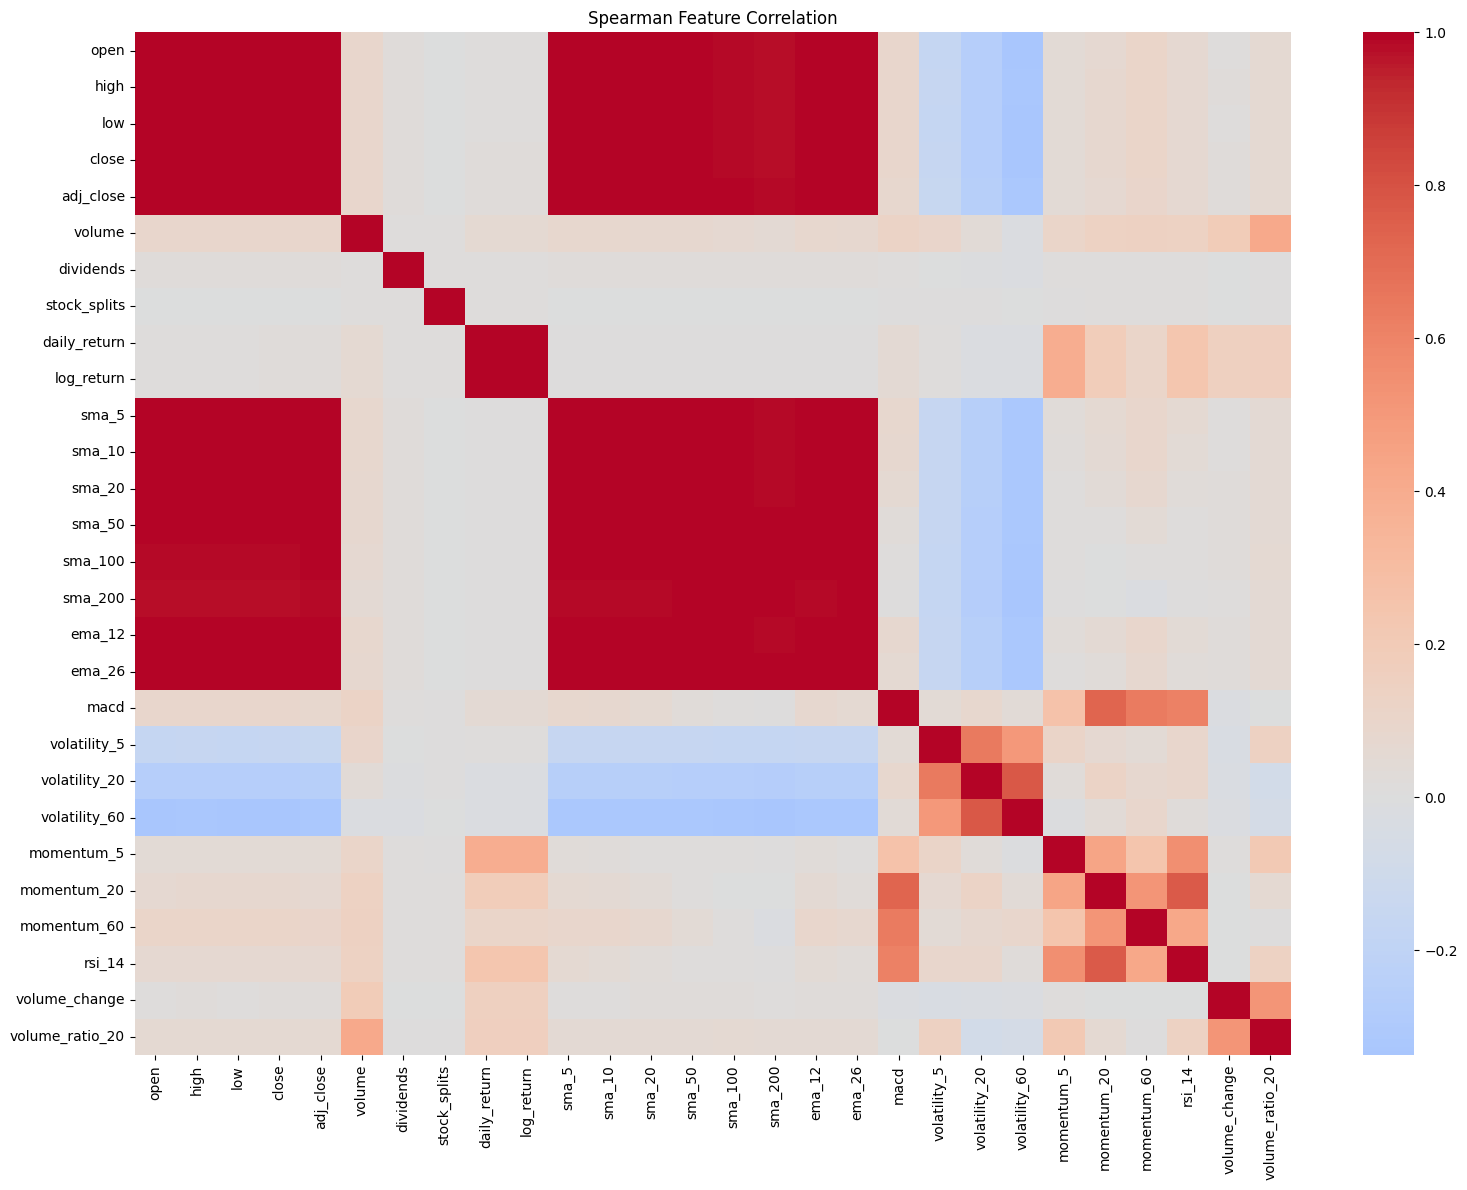

In [30]:
corr = model_df[
    FEATURE_COLUMNS
].corr(
    method="spearman"
)

plt.figure(
    figsize=(16, 12)
)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Spearman Feature Correlation"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "feature_correlation.png",
    dpi=150
)

plt.show()

In [31]:
corr_pairs = []

for i in range(len(corr.columns)):

    for j in range(i + 1, len(corr.columns)):

        value = corr.iloc[i, j]

        if abs(value) >= 0.90:

            corr_pairs.append({
                "feature_1": corr.columns[i],
                "feature_2": corr.columns[j],
                "spearman_corr": value
            })

high_corr = pd.DataFrame(
    corr_pairs
).sort_values(
    "spearman_corr",
    key=lambda x: abs(x),
    ascending=False
)

display(high_corr.head(50))

,feature_1,feature_2,spearman_corr
50,daily_return,log_return,1.000000
62,sma_10,ema_12,0.999956
23,low,close,0.999901
68,sma_20,ema_26,0.999893
13,high,close,0.999886
0,open,high,0.999873
1,open,low,0.999861
51,sma_5,sma_10,0.999826
56,sma_5,ema_12,0.999820
2,open,close,0.999798


# ***TARGET DISTRIBUTION***

count    7.632492e+06
mean     3.625806e-03
std      2.538383e+00
min     -2.946443e+01
1%      -7.476636e-02
5%      -4.535480e-02
25%     -1.469539e-02
50%      0.000000e+00
75%      1.321305e-02
95%      4.999995e-02
99%      1.001033e-01
max      3.369478e+03
Name: target_next_day_return, dtype: float64


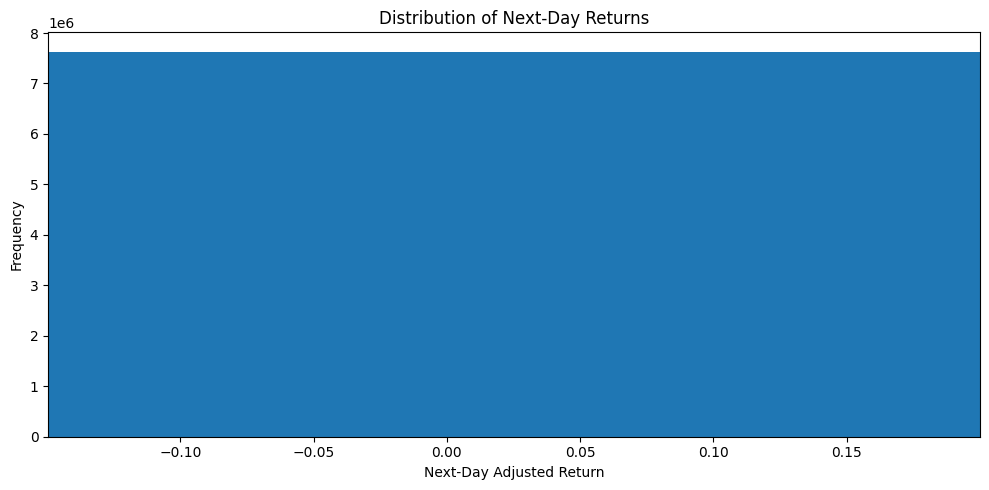

In [32]:
target = model_df[
    "target_next_day_return"
]

print(target.describe(
    percentiles=[
        .01,
        .05,
        .25,
        .50,
        .75,
        .95,
        .99
    ]
))

plt.figure(figsize=(10, 5))

plt.hist(
    target.dropna(),
    bins=200
)

plt.xlabel(
    "Next-Day Adjusted Return"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Next-Day Returns"
)

plt.xlim(
    target.quantile(.001),
    target.quantile(.999)
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "target_distribution.png",
    dpi=150
)

plt.show()

# ***YEARLY OBSERVATION***

year
1991       260
1992       262
1993       261
1994       260
1995       260
1996     16257
1997     16887
1998     17265
1999     21123
2000     23170
2001     24914
2002     81242
2003    141040
2004    150096
2005    155428
2006    173087
2007    203036
2008    223793
2009    226262
2010    247804
2011    259351
2012    270032
2013    279091
2014    279426
2015    292657
2016    308982
2017    337758
2018    366620
2019    378024
2020    402475
2021    417457
2022    446767
2023    464637
2024    494673
2025    536653
2026    435230
dtype: int64

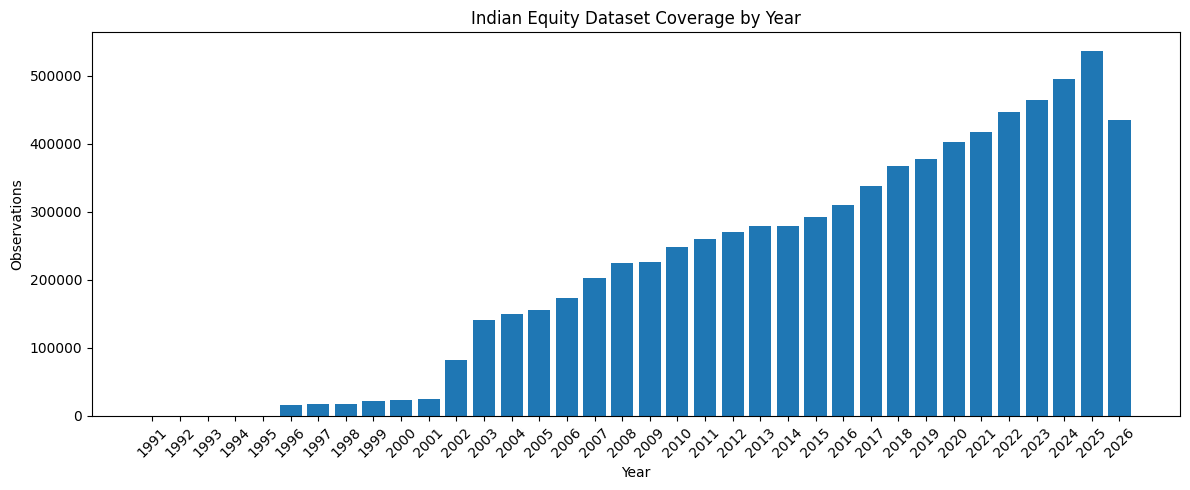

In [33]:
df["year"] = df["date"].dt.year

year_counts = (
    df.groupby("year")
      .size()
)

display(year_counts)

plt.figure(figsize=(12, 5))

plt.bar(
    year_counts.index.astype(str),
    year_counts.values
)

plt.xticks(rotation=45)

plt.xlabel("Year")
plt.ylabel("Observations")

plt.title(
    "Indian Equity Dataset Coverage by Year"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "observations_by_year.png",
    dpi=150
)

plt.show()

# ***TRADING-DAY GAP AUDIT***

In [34]:
df_sorted = df.sort_values(
    ["symbol", "date"]
).copy()

df_sorted["days_since_previous"] = (
    df_sorted
    .groupby("symbol")["date"]
    .diff()
    .dt.days
)

gap_summary = (
    df_sorted[
        df_sorted["days_since_previous"] > 10
    ][
        [
            "symbol",
            "date",
            "days_since_previous"
        ]
    ]
    .sort_values(
        "days_since_previous",
        ascending=False
    )
)

print(
    "Large gaps (>10 calendar days):",
    len(gap_summary)
)

display(
    gap_summary.head(50)
)

Large gaps (>10 calendar days): 23


,symbol,date,days_since_previous
6142081,SICAGEN,2026-04-15,1722.0
492152,ARIHANT,2026-04-13,1523.0
3932627,LANCER,2026-08-20,1210.0
377453,ANDREWYU,2026-08-17,985.0
3706324,KENNAMET,2026-04-15,861.0
4805079,NOVARTIND,2026-04-15,861.0
2515527,GOODYEAR,2026-04-15,861.0
3763804,KIRLFER,2026-04-13,859.0
3850974,KOVAI,2026-04-13,859.0
2547474,GRAUWEIL,2026-04-13,859.0


# ***SAVING AUDITTED DATA***

In [35]:
OUTPUT_DATA = (
    OUTPUT_DIR /
    "indian_stock_modeling_dataset.parquet"
)

model_df.to_parquet(
    OUTPUT_DATA,
    index=False
)

print(
    "Saved:",
    OUTPUT_DATA
)

print(
    "Rows:",
    f"{len(model_df):,}"
)

print(
    "Columns:",
    len(model_df.columns)
)

Saved: indian_market_audit/indian_stock_modeling_dataset.parquet
Rows: 7,632,492
Columns: 32


In [36]:
audit_summary = {
    "rows": int(len(df)),
    "columns": int(len(df.columns)),
    "symbols": int(df["symbol"].nunique()),
    "start_date": str(df["date"].min()),
    "end_date": str(df["date"].max()),

    "exact_duplicates": int(
        df.duplicated().sum()
    ),

    "symbol_date_duplicates": int(
        df.duplicated(
            ["symbol", "date"]
        ).sum()
    ),

    "negative_volume": int(
        (df["volume"] < 0).sum()
    ),

    "bad_high_low": int(
        (df["high"] < df["low"]).sum()
    ),

    "nonpositive_close": int(
        (df["close"] <= 0).sum()
    ),

    "extreme_returns_gt_20pct": int(
        (
            df["daily_return"].abs() > .20
        ).sum()
    ),

    "split_events": int(
        len(split_events)
    ),

    "dividend_events": int(
        len(dividend_events)
    )
}

print(
    json.dumps(
        audit_summary,
        indent=4
    )
)

with open(
    OUTPUT_DIR / "audit_summary.json",
    "w"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=4
    )

{
    "rows": 7692540,
    "columns": 42,
    "symbols": 2624,
    "start_date": "1991-01-02 00:00:00",
    "end_date": "2026-09-25 00:00:00",
    "exact_duplicates": 0,
    "symbol_date_duplicates": 0,
    "negative_volume": 0,
    "bad_high_low": 1,
    "nonpositive_close": 0,
    "extreme_returns_gt_20pct": 7894,
    "split_events": 1575,
    "dividend_events": 24112
}
